In [5]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

#Load dataset
data = pd.read_csv("oil_by_country.csv")

# Clean column names 
data.columns = data.columns.str.strip()

#Handle missing values
data = data.dropna()

#Create target variable
data['Oil_Transport'] = data['Exports'] + data['Imports']

#Encode Country
le = LabelEncoder()
data['Country'] = le.fit_transform(data['Country'])

#Select features (better version without weak dependency)
X = data[['Proven_reserves', 'Production', 'Consumption']]
y = data['Oil_Transport']

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Train model
model = LinearRegression()
model.fit(X_train, y_train)

#Prediction
y_pred = model.predict(X_test)

#Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

#Test with new input (India example)
new_data = pd.DataFrame({
    'Proven_reserves': [5476000000],
    'Production': [772100],
    'Consumption': [3292000]
})

prediction = model.predict(new_data)
print("Predicted Oil Transport:", prediction[0])

MSE: 91984298135.71027
R2 Score: 0.6772164778155919
Predicted Oil Transport: 1731136.8800989836


In [13]:
# predictthe total oil transport
new_data = pd.DataFrame({
    'Proven_reserves': [5476000000],
    'Production': [772100],
    'Consumption': [3292000]
})

prediction = model.predict(new_data)

print("Predicted Oil Transport",prediction[0])

Predicted Oil Transport 1731136.8800989836


In [14]:
#export prediction based on the data set



X = data[['Proven_reserves', 'Production', 'Consumption']]
y_export = data['Exports']

X_train, X_test, y_train, y_test = train_test_split(X, y_export, test_size=0.2, random_state=42)

model_export = LinearRegression()
model_export.fit(X_train, y_train)

y_pred_export = model_export.predict(X_test)

print("Export Prediction R2:", r2_score(y_test, y_pred_export))

#“An R² score of 0.82 indicates that the model has strong predictive power and captures most of the underlying relationship between input features and export values.”
#“It means the model explains 82% of the variation or pattern in export values, showing strong understanding of how exports depend on the input features.”

Export Prediction R2: 0.8221931293075062


In [15]:
#import prediction based on tha dataset 



y_import = data['Imports']

X_train, X_test, y_train, y_test = train_test_split(X, y_import, test_size=0.2, random_state=42)

model_import = LinearRegression()
model_import.fit(X_train, y_train)

y_pred_import = model_import.predict(X_test)

print("Import Prediction R2:", r2_score(y_test, y_pred_import))

Import Prediction R2: 0.8064563097320308


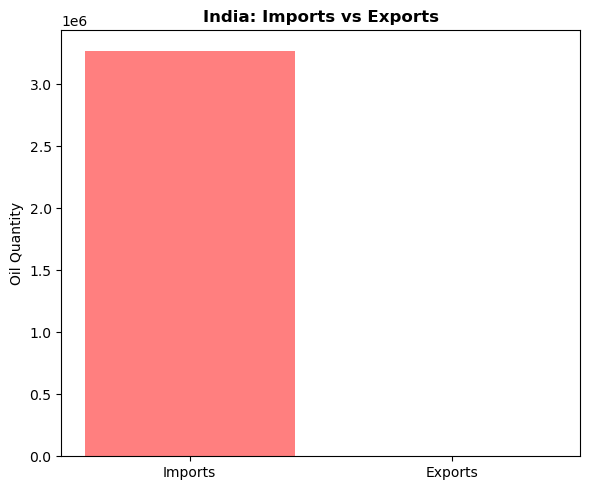

In [27]:
#total import and exort by india 



import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("oil_by_country.csv")
df.columns = df.columns.str.strip()
india = df[df["Country"] == "India"]

imports = india["Imports"].values[0]
exports = india["Exports"].values[0]


plt.figure(figsize=(6,5))
plt.bar(["Imports", "Exports"], [imports, exports],color=("red","green"),alpha=0.5)
plt.title("India: Imports vs Exports", fontweight="bold")
plt.ylabel("Oil Quantity")

plt.tight_layout()

plt.show()

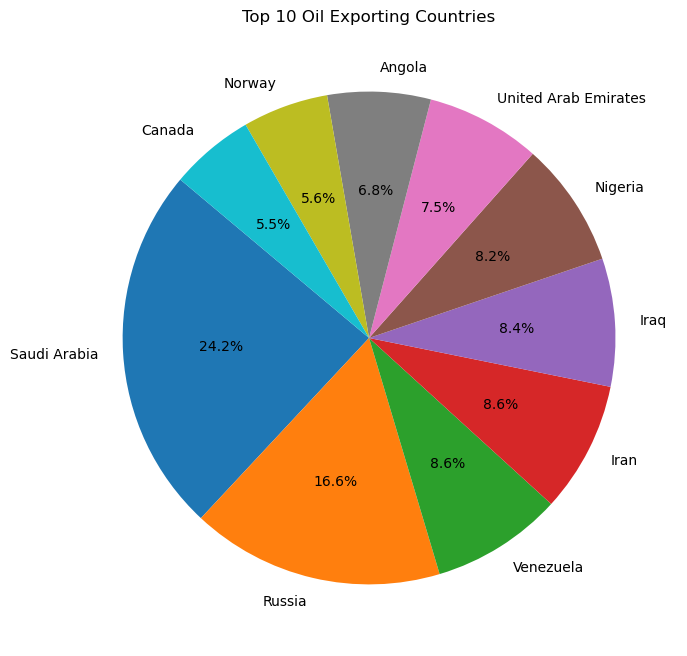

In [30]:
#in this with the help of the visualization find the top 10 exporting countries

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("oil_by_country.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Get Top 10 exporting countries
top10 = df.sort_values(by="Exports", ascending=False).head(10)

# Pie chart
plt.figure(figsize=(7,7))

plt.pie(
    top10["Exports"],
    labels=top10["Country"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Top 10 Oil Exporting Countries")

plt.tight_layout()
plt.savefig("top10_exports_pie.png", dpi=300, bbox_inches='tight')
plt.show()

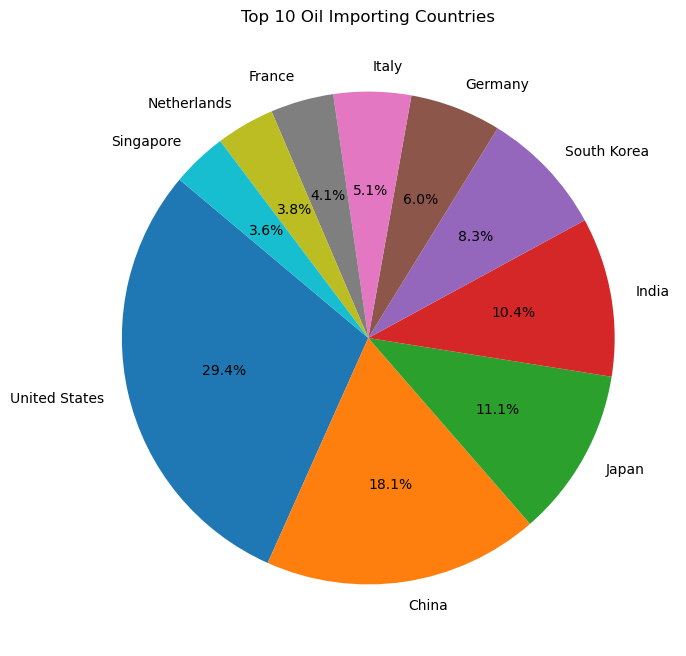

In [31]:
#in this with the help of the visualization find the top 10 importing countries
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("oil_by_country.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Get Top 10 importing countries
top10 = df.sort_values(by="Imports", ascending=False).head(10)

# Pie chart
plt.figure(figsize=(7,7))

plt.pie(
    top10["Imports"],
    labels=top10["Country"],
    autopct="%1.1f%%",
    startangle=140
)

plt.title("Top 10 Oil Importing Countries")

plt.tight_layout()
plt.savefig("top10_imports_pie.png", dpi=300, bbox_inches='tight')
plt.show()

In [32]:
# get the highest import country 

import pandas as pd

df = pd.read_csv("oil_by_country.csv")
df.columns = df.columns.str.strip()


top_import_country = df.loc[df["Imports"].idxmax()]

print("Top Importing Country:")
print(top_import_country["Country"])

print("Import Value:")
print(top_import_country["Imports"])

Top Importing Country:
United States
Import Value:
9213000.0


In [33]:
import pandas as pd

df = pd.read_csv("oil_by_country.csv")
df.columns = df.columns.str.strip()

# Get highest exporting country
top_export = df.loc[df["Exports"].idxmax()]

print("Highest Exporting Country:", top_export["Country"])
print("Export Value:", top_export["Exports"])

Highest Exporting Country: Saudi Arabia
Export Value: 6880000.0
